# 7.2.1 从条件概率到预测与更新

## 学习目标与先修知识

由边缘化和Bayes公式推导滤波，正确处理缺测和零证据。

先修：7.1的状态（state）模型（model）及第5篇边缘概率（probability）、条件概率（conditional probability）和Bayes公式。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

某个细胞的标记强度有噪声。观察到强标记后，“活跃概率”是不是直接等于传感器在活跃状态下产生强标记的概率？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
prior=np.array([.6,.4]);likelihood=np.array([.2,.8]);mass=prior*likelihood
print('未归一化质量=',mass,'证据=',mass.sum(),'后验=',mass/mass.sum())

未归一化质量= [0.12 0.32] 证据= 0.44000000000000006 后验= [0.27272727 0.72727273]


## 模型假设

隐藏状态有限，转移概率已知。似然（likelihood）描述给定隐藏状态产生当前读数的可能性，不是状态概率。缺测（missing observation）按没有新增信息处理；先假设缺测机制不依赖未知状态，否则“未测到”本身可能携带信息。

## 数学解释与推导

令 $\alpha_{t-1}(i)=p(z_{t-1}=i\mid y_{0:t-1})$，$T_{ij}=p(z_t=j\mid z_{t-1}=i)$。对上一步状态求和：
$$\pi_t(j)=\sum_i\alpha_{t-1}(i)T_{ij}.$$
当前读数的似然为 $\ell_t(j)=p(y_t\mid z_t=j)$。Bayes公式给出
$$Z_t=\sum_j\ell_t(j)\pi_t(j),\qquad\alpha_t(j)=\frac{\ell_t(j)\pi_t(j)}{Z_t}.$$
$Z_t$是证据（evidence）；本节的离散标记模型中它是该读数条件概率。连续观测（observation）时它通常是概率密度（probability density），不要求小于1。时刻0没有先前转移，$\pi_0$就是初始先验（prior）。

连续状态对应把求和改成积分：$p(x_t\mid y_{<t})=\int p(x_t\mid x_{t-1})p(x_{t-1}\mid y_{<t})dx_{t-1}$。随后依旧乘似然并归一化。缺测用常数似然1；零证据意味着当前模型不允许该事件（event），不能凭空产生均匀后验（posterior）。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型与当时可用的信息。

In [3]:
def hmm_filter(initial, transition, likelihoods):
    posterior = np.array(initial, float)
    transition = np.array(transition, float)
    result = dict(predictions=[], posteriors=[], evidence=[], status='ok')
    for t, likelihood in enumerate(likelihoods):
        prediction = posterior if t == 0 else posterior @ transition
        likelihood = np.ones(len(initial)) if likelihood is None else np.array(likelihood, float)
        mass = prediction * likelihood
        evidence = float(mass.sum())
        result['predictions'].append(prediction.tolist())
        result['evidence'].append(evidence)
        if evidence <= 0:
            result['status'] = 'impossible'
            return result
        posterior = mass / evidence
        result['posteriors'].append(posterior.tolist())
    return result

## 对照实验

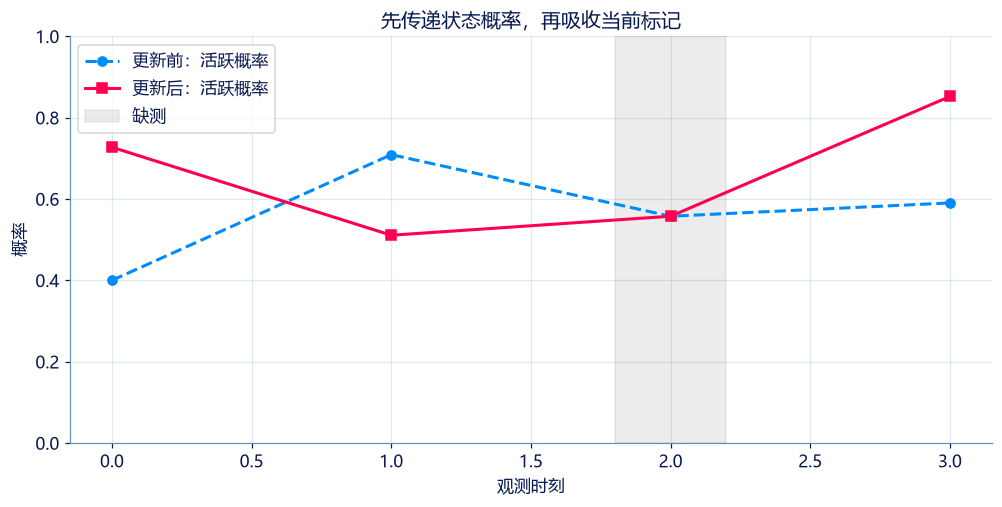

In [4]:
initial=[.6,.4];transition=[[.8,.2],[.1,.9]];likelihoods=[[.2,.8],[.7,.3],None,[.2,.8]]
run=hmm_filter(initial,transition,likelihoods)
fig,ax=plt.subplots(figsize=(9,4.5));ax.plot(np.array(run['predictions'])[:,1],'o--',label='更新前：活跃概率');ax.plot(np.array(run['posteriors'])[:,1],'s-',label='更新后：活跃概率');ax.axvspan(1.8,2.2,color='gray',alpha=.15,label='缺测');ax.set(xlabel='观测时刻',ylabel='概率',ylim=(0,1),title='先传递状态概率，再吸收当前标记');ax.legend();plt.show()

### 独立核验与边界

In [5]:
np.testing.assert_allclose(run['posteriors'][0],[3/11,8/11])
np.testing.assert_allclose(run['predictions'][2],run['posteriors'][2])
assert hmm_filter([1,0],[[1,0],[0,1]],[[0,1]])['status']=='impossible'
assert hmm_filter(initial,transition,[])['posteriors']==[]
assert all(abs(sum(p)-1)<1e-12 for p in run['posteriors'])
print('首步手算、缺测、零证据与概率归一化通过。')

首步手算、缺测、零证据与概率归一化通过。


## 结果解释

相同似然在不同先验上得到不同后验。缺测时预测与后验重合，但时间仍推进，状态概率可能因转移而变化。零证据分支显式停止，避免将模型不支持的事件包装成一个看似正常的答案。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：逐次预测与更新

在有限状态（state）模型（model）中递推观测（observation）后验（posterior）。第0时刻先验（prior）就是 initial，不先转移；后续先转移再使用当时似然（likelihood）。

**函数与代码模板**

```python
def solve(
    initial: list[float],
    transition: list[list[float]],
    likelihoods: list[list[float] | None],
) -> tuple[list[list[float]], list[list[float]], list[float], str]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[float]` | 时刻 0 的观测前概率分布（probability distribution）。 | 概率 |
| `transition` | `list[list[float]]` | 第 i 行第 j 列为从 i 转移到 j 的概率（probability）。 | 概率 |
| `likelihoods` | <code>list[list[float] &#124; None]</code> | 各时刻实际读数在各状态下的似然；None 表示缺测。 | 无量纲 |

**返回值**

按以下顺序返回元组：(predictions, posteriors, evidence, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `predictions` | `list[list[float]]` | 每一步观测前分布（distribution）。 | 概率 |
| `posteriors` | `list[list[float]]` | 成功归一化各步的滤波后验。 | 概率 |
| `evidence` | `list[float]` | 各步似然加权和。 | 无量纲 |
| `status` | `str` | 成功为 ok；首个零证据为 impossible。 | 无量纲 |

**计算规则**

prediction[0]=initial；prediction[t]=posterior[t−1]@transition。逐分量乘似然后除以和。None似然等价全1；零证据时保留该步prediction和0证据，停止且不新增该步后验。

**约束与边界**

- 状态数2—3，序列长度0—20；初始和各转移行均非负且和为1。
- 似然在[0,1]；允许零证据，不擅自改为均匀分布。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 时刻 0 的观测前概率分布（probability distribution）。 | [0.6, 0.4] | 概率 |
| transition | 第 i 行第 j 列为从 i 转移到 j 的概率（probability）。 | [[0.8, 0.2], [0.1, 0.9]] | 概率 |
| likelihoods | 各时刻实际读数在各状态下的似然；None 表示缺测。 | [[0.2, 0.8], [0.7, 0.3]] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [0.6, 0.4]
transition = [[0.8, 0.2], [0.1, 0.9]]
likelihoods = [[0.2, 0.8], [0.7, 0.3]]

result = solve(initial, transition, likelihoods)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| predictions | 每一步观测前分布（distribution）。 | [[0.6, 0.4], [0.2909090909090909, 0.7090909090909091]] | 概率 |
| posteriors | 成功归一化各步的滤波后验。 | [[0.2727272727272727, 0.7272727272727273], [0.48908296943231433, 0.5109170305676856]] | 概率 |
| evidence | 各步似然加权和。 | [0.44000000000000006, 0.4163636363636364] | 无量纲 |
| status | 成功为 ok；首个零证据为 impossible。 | ok | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.6, 0.4],
                    [0.2909090909090909,
                     0.7090909090909091]],
                   [[0.2727272727272727,
                     0.7272727272727273],
                    [0.48908296943231433,
                     0.5109170305676856]],
                   [0.44000000000000006,
                    0.4163636363636364],
                   'ok')
```

**样例解释**

第一步质量[0.12,0.32]，证据0.44，后验约[0.272727,0.727273]；第二步必须先转移。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：逐次预测与更新](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-bayes-sequence)

### 第 2 题 · 单项选择题：归一化的分母是什么

先验（prior）[0.6,0.4]，某观测（observation）在两个状态（state）下的似然（likelihood）[0.2,0.8]。哪项正确？

- **A.** 后验（posterior）直接是[0.2,0.8]。
- **B.** 证据为0.44，后验为[3/11,8/11]。
- **C.** 证据为1。
- **D.** 先验与观测无关，因此可以忽略。

[作答：归一化的分母是什么](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-evidence-normalization)

### 第 3 题 · 多项选择题：缺测等于观测零吗

当前没有读数。哪些处理成立？

- **A.** 令似然（likelihood）为常数1，只做预测。
- **B.** 必须用观测（observation）值0更新。
- **C.** 用以后到达的读数填入后仍称实时滤波。
- **D.** 保留当前预测作为滤波结果。

[作答：缺测等于观测零吗](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-missing-not-zero)

### 第 4 题 · 单项选择题：不可能观测之后

先验（prior）只支持状态（state）0，似然（likelihood）在状态0严格为0。哪项恰当？

- **A.** 后验（posterior）均匀。
- **B.** 把零分母改成极小数即可获得正确条件分布（distribution）。
- **C.** 该模型（model）把事件（event）赋予零概率（probability），后验未定义，应检查模型或数据。
- **D.** 选择似然最大的状态就是精确Bayes更新。

[作答：不可能观测之后](http://127.0.0.1:8000/chapters/07-02-%E8%B4%9D%E5%8F%B6%E6%96%AF%E9%80%92%E6%8E%A8%E4%B8%8E%E9%9A%90%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p07-zero-evidence)

### 延伸阅读

R26，第2、6章的条件概率与Bayes滤波。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-02-贝叶斯递推与隐马尔可夫模型/explore/) · [本篇目录](../README.md)